## Structuration des data

### Organisation

les données brutes sont enregistrées dans le dossier **RAW_DATA** (en lecture seule), les données traitées dans un dossier **PROCESSED_DATA**

les RAW_DATA sont rangées comme suit: 

    RAW_DATA/sample/sample_{datasetA,..., datasetN}

Pour chaque dataset, il y a un fichier de métadonnées h5 qui a un softlink vers les images, c'est RAW_DATA/sample/sample_datasetA/sample_datasetA.h5

Généralement pour le post-processing "classique" on peut lire les images depuis ce fichier c'est assez rapide.

Ensuite mettons que dans mon datasetA, je sauvegarde d'abord une image juste pour avoir un état initial, ensuite je lance un loopscan, et enfin je resauvegarde une image à la fin. Il y a 3 séries d'acquisition (on aura tapé 3 commandes manuellement, ou via la macro, pour lancer ces acquisitions). Ces 3 scans seront dans: 

    RAW_DATA/sample/sample_datasetA/{scan001,scan002,scan003} 
    Mais je peux aussi y accéder via le fihcier de metadonnées du dataset: RAW_DATA/sample/sample_datasetA/sample_datasetA.h5::{1.1/measurement/eiger, 2.1/measurement/eiger, 3.1/measurement/eiger}

Dans l'exemple fourni, le sample est CeO2, le datasetA est CeO2_rot.Le dossier **CeO2_rot** contient les éléments suivants:
- un fichier de métadonnées CeO2_rot.h5 (avec en principe le softlink vers les images)
- un dossier scan0001 qui contient le fichier avec les images (eiger_0000.h5)


## Étape 1 : identification des chemins de métadonnées et softlinks

Exploration de `CeO2_rot.h5` (exemple `fscan diffrz`, scan `1.1`). Les chemins ci-dessous sont génériques (valables pour tout numéro d'entrée `N.M`, ici `1.1`).

### Softlink vers les images

- `N.M/measurement/eiger` → softlink interne vers `N.M/instrument/eiger/image`
- `N.M/instrument/eiger/image` est un **Virtual Dataset (VDS)** qui pointe vers le fichier brut : `scanXXXX/eiger_0000.h5::/entry_0000/ESRF-ID11/eiger/data`
  (chemin relatif au dossier du fichier `.h5` de métadonnées ; accessible via `dataset.virtual_sources()` si besoin de retrouver le fichier physique)
- Métadonnées d'acquisition associées : `N.M/instrument/eiger/acq_parameters/{acq_expo_time, acq_nb_frames, latency_time, acq_trigger_mode, saving_directory}`

### Position des moteurs

Le moteur qui bouge pendant le scan (ex. `diffrz` pour un `fscan diffrz`, ou `samty`/`samtz` pour un scan sur ces axes) se trouve dans `measurement` avec un tableau (une valeur par point). Les moteurs fixes se trouvent dans `positioners` avec une valeur scalaire.

- Moteurs fixes (scalaires) : `N.M/instrument/positioners/{difftz, samtz, samty}`
- Moteurs mobiles (tableaux, un point par frame) : `N.M/measurement/{samty, samtz, diffrz, ...}` (dépend du type de scan)
- Positions figées en début/fin de scan (utile en complément) : `N.M/instrument/positioners_start/...` et `N.M/instrument/positioners_end/...`

### Métadonnées temporelles

- `N.M/start_time`, `N.M/end_time` : timestamps ISO 8601 (début/fin du scan)
- `N.M/end_reason` : statut de fin (`SUCCESS`, ...)
- `N.M/writer/date`, `N.M/writer/status` : horodatage et statut de l'écriture du fichier
- `N.M/instrument/epoch_trig/data` : epoch Unix (s) par frame
- `N.M/instrument/sec/data` : temps d'exposition effectif par frame (s)
- `N.M/instrument/timer_raw/data`, `timer_delta/data`, `timer_period/data`, `timer_trig/data` : compteurs temporels bruts / intervalles / période par frame (s)
- `N.M/instrument/eiger/acq_parameters/acq_expo_time` : temps d'exposition programmé (s)
- `N.M/instrument/eiger/acq_parameters/latency_time` : latence entre frames (s)

### Autres métadonnées utiles

- `N.M/sample/name` : nom de l'échantillon
- `N.M/title` : commande du scan (permet de détecter le type : `fscan`, `loopscan`, ...)


## Test de la classe EigerData

L'idée est que XRDProcessor hérite ensuite des attributs de EigerData

In [1]:
#%matplotlib widget
from xpdfsuite_ID11 import EigerData
import os


path = '/home-local/ratel-ra/Documents/PDF_data/ESRF_ID11_2026/test_data/CeO2_eiger_ok/CeO2/CeO2_rot/'
h5file = os.path.join(path, 'CeO2_rot.h5') 
eiger_data = EigerData(h5file)
eiger_data.get_eiger_source()

{'vds_path': '1.1/measurement/eiger',
 'shape': (72, 2162, 2068),
 'dtype': dtype('uint32'),
 'real_file': 'scan0001/eiger_0000.h5',
 'real_dataset': '/entry_0000/ESRF-ID11/eiger/data'}

{'diffrz': array([  2.49995,   7.4998 ,  12.49965,  17.49945,  22.4992 ,  27.49905,
        32.4989 ,  37.49865,  42.49845,  47.4983 ,  52.4981 ,  57.4979 ,
        62.4977 ,  67.4975 ,  72.4973 ,  77.49715,  82.49695,  87.49675,
        92.4966 ,  97.49635, 102.49615, 107.496  , 112.49585, 117.49565,
       122.49535, 127.49525, 132.49505, 137.4948 , 142.4946 , 147.4944 ,
       152.4942 , 157.49405, 162.4939 , 167.4937 , 172.4935 , 177.4933 ,
       182.49305, 187.49285, 192.4927 , 197.49245, 202.49225, 207.4921 ,
       212.4919 , 217.4917 , 222.4915 , 227.4913 , 232.4911 , 237.4909 ,
       242.4907 , 247.4905 , 252.4903 , 257.4901 , 262.4899 , 267.48975,
       272.48955, 277.4894 , 282.4892 , 287.48895, 292.48865, 297.4885 ,
       302.4883 , 307.48805, 312.4879 , 317.48765, 322.4874 , 327.48725,
       332.4871 , 337.48685, 342.48665, 347.48645, 352.48625, 357.4861 ])}


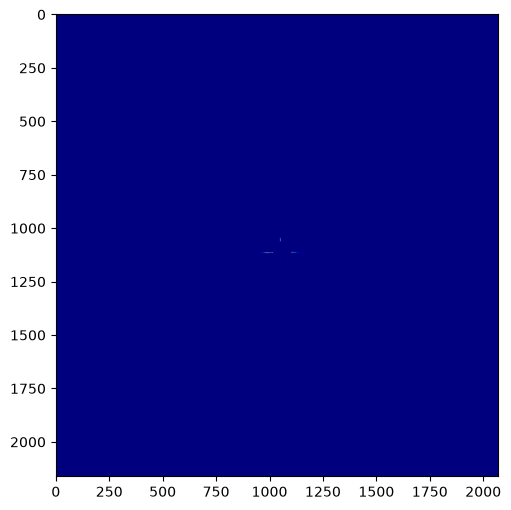

In [2]:
# Accès aux moteurs qui ont été scannés
print(eiger_data.positions['measurement'])

from matplotlib import pyplot as plt
plt.figure(figsize=(6, 6))
plt.imshow(eiger_data.data[eiger_data.nb_frames-1], cmap='jet')
eiger_data.close()  # Fermer le fichier HDF5 lorsque vous avez terminé

**Test xpdfsuite**

samplename: CeO2
command: fscan diffrz 0 5 72 0.5 0.500019
scanned motors: {'diffrz': array([  2.49995,   7.4998 ,  12.49965,  17.49945,  22.4992 ,  27.49905,
        32.4989 ,  37.49865,  42.49845,  47.4983 ,  52.4981 ,  57.4979 ,
        62.4977 ,  67.4975 ,  72.4973 ,  77.49715,  82.49695,  87.49675,
        92.4966 ,  97.49635, 102.49615, 107.496  , 112.49585, 117.49565,
       122.49535, 127.49525, 132.49505, 137.4948 , 142.4946 , 147.4944 ,
       152.4942 , 157.49405, 162.4939 , 167.4937 , 172.4935 , 177.4933 ,
       182.49305, 187.49285, 192.4927 , 197.49245, 202.49225, 207.4921 ,
       212.4919 , 217.4917 , 222.4915 , 227.4913 , 232.4911 , 237.4909 ,
       242.4907 , 247.4905 , 252.4903 , 257.4901 , 262.4899 , 267.48975,
       272.48955, 277.4894 , 282.4892 , 287.48895, 292.48865, 297.4885 ,
       302.4883 , 307.48805, 312.4879 , 317.48765, 322.4874 , 327.48725,
       332.4871 , 337.48685, 342.48665, 347.48645, 352.48625, 357.4861 ])}
number of frames: 72


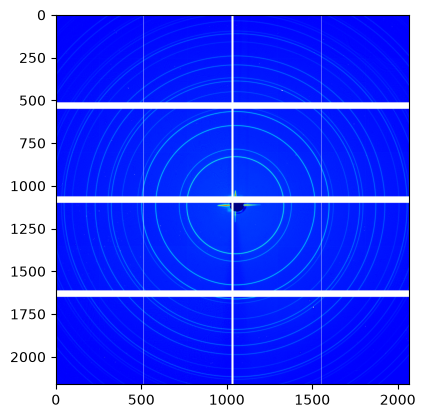

In [3]:
from xpdfsuite_ID11 import XRDProcessor
import os

datapath = '/home-local/ratel-ra/Documents/PDF_data/ESRF_ID11_2026/test_data/CeO2_eiger_ok/'
sample = 'CeO2'
dataset = 'CeO2_rot'
h5file = os.path.join(datapath, sample, dataset,dataset + '.h5')
poni_file = os.path.join(datapath,'CeO2.poni')
mask = os.path.join(datapath,'mask_hand.edf')

processor = XRDProcessor(h5file, frame='mean', poni_file=poni_file, mask=mask, verbose=True)

print(f'samplename: {processor.samplename}')
print(f'command: {processor.command}')
print(f'scanned motors: {processor.scanned_motors}')
nb_frames = processor.nb_frames
print(f'number of frames: {nb_frames}')

processor.plot()



In [4]:
processor.close()

**Test plot vs. motor positions**

KeyboardInterrupt: 

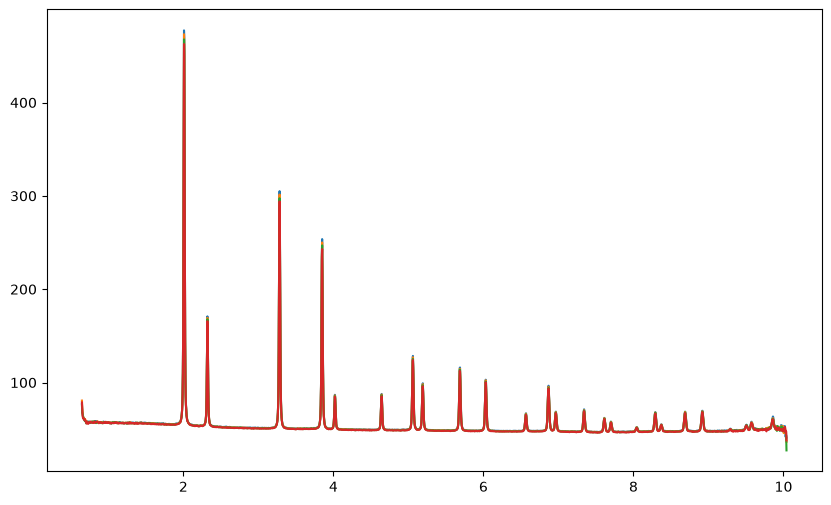

In [5]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
for frame in range(nb_frames):
    processor = XRDProcessor(h5file, frame=frame, poni_file=poni_file, mask=mask)
    # retrieve the motor position for the current frame
    motor_pos = processor.scanned_motors[list(processor.scanned_motors.keys())[0]][frame]
   
    q,I=processor.integrate(plot=False)
    plt.plot(q, I, label=f'Motor position: {motor_pos:.2f}')
    processor.close() # fermeture du fichier HDF5 après le traitement
plt.legend()

In [ ]:
from xpdfsuite_ID11 import extract_xpdf

r,G = extract_xpdf(processor,
             composition = 'CeO2',
             rmin=0,
             rmax=100,
             rstep=0.02,
             interactive=True)
             

**Test draw_mask**

In [ ]:
from xpdfsuite_ID11.utilities import draw_mask

draw_mask(h5file)

**Test geometric_calibration**

In [ ]:
from xpdfsuite_ID11.calibration import perform_geometric_calibration

cif = '/home-local/ratel-ra/Documents/CIF_database/CeO2_Fm3m.cif'
wavelength = 0.2846350890360207
perform_geometric_calibration(cif_file=cif, image_file=h5file, wavelength=wavelength)

**Test process_lost_flow**

Processing frame group: [0, 1, 8, 9, 16, 17, 24, 25, 32, 33, 40, 41, 48, 49, 56, 57, 64, 65]
Compute PDF with given parameters
PDF saved to /home-local/ratel-ra/Documents/PDF_data/ESRF_ID11_2026/test_data/CeO2_eiger_ok/CeO2/CeO2_rot/CeO2_rot_frames=0-65.gr
Processing frame group: [2, 3, 10, 11, 18, 19, 26, 27, 34, 35, 42, 43, 50, 51, 58, 59, 66, 67]
Compute PDF with given parameters
PDF saved to /home-local/ratel-ra/Documents/PDF_data/ESRF_ID11_2026/test_data/CeO2_eiger_ok/CeO2/CeO2_rot/CeO2_rot_frames=2-67.gr
Processing frame group: [4, 5, 12, 13, 20, 21, 28, 29, 36, 37, 44, 45, 52, 53, 60, 61, 68, 69]
Compute PDF with given parameters
PDF saved to /home-local/ratel-ra/Documents/PDF_data/ESRF_ID11_2026/test_data/CeO2_eiger_ok/CeO2/CeO2_rot/CeO2_rot_frames=4-69.gr
Processing frame group: [6, 7, 14, 15, 22, 23, 30, 31, 38, 39, 46, 47, 54, 55, 62, 63, 70, 71]
Compute PDF with given parameters
PDF saved to /home-local/ratel-ra/Documents/PDF_data/ESRF_ID11_2026/test_data/CeO2_eiger_ok/CeO2

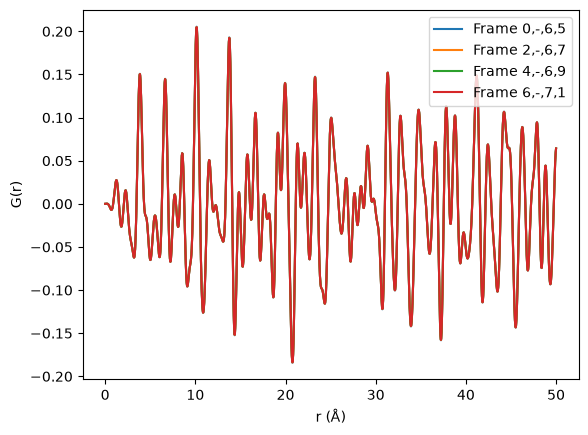

In [2]:
from xpdfsuite_ID11.utilities_process import process_lost_flow
import os


datapath = '/home-local/ratel-ra/Documents/PDF_data/ESRF_ID11_2026/test_data/CeO2_eiger_ok/'
sample = 'CeO2'
dataset = 'CeO2_rot'
h5file = os.path.join(datapath, sample, dataset,dataset + '.h5')
poni_file = os.path.join(datapath,'CeO2.poni')
mask = os.path.join(datapath,'mask_hand.edf')


pdffiles, res = process_lost_flow(file=h5file,
                      poni_file=poni_file,
                      mask_file=mask,
                      polarization = 0.99,
                      plot=True,
                      rmin = 0,
                      rmax = 50,
                      rstep = 0.02,
                      qmax = 10,
                      qmaxinst = 10,
                      rpoly = 0.9,
                      frame_binning = 2,
                      frame_step = 8,)

In [8]:
# Visualize res dict key wise
for key, value in res.items():
    print(f"Frame group: {key}")
    for subkey, subvalue in value.items():
        print(f"  {subkey}: {subvalue}")


Frame group: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
  position: {'diffrz': 59.99780625}
  r: [0.000e+00 2.000e-02 4.000e-02 ... 4.996e+01 4.998e+01 5.000e+01]
  G: [0.00000000e+00 1.76342162e-05 3.45254489e-05 ... 5.81632461e-02
 6.11838134e-02 6.35139411e-02]
Frame group: [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
  position: {'diffrz': 179.9931625}
  r: [0.000e+00 2.000e-02 4.000e-02 ... 4.996e+01 4.998e+01 5.000e+01]
  G: [ 0.00000000e+00 -4.10382978e-05 -8.70442186e-05 ...  7.01927644e-02
  7.27003643e-02  7.43999617e-02]
Frame group: [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71]
  position: {'diffrz': 299.98839375}
  r: [0.000e+00 2.000e-02 4.000e-02 ... 4.996e+01 4.998e+01 5.000e+01]
  G: [0.00000000e+00 9.73827880e-05 1.99794491e-04 ... 4.81474532e-02
 4.99912083e-02 5.12715385e-02]
